In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import  LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [2]:
housing = fetch_california_housing()

In [3]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [4]:
# convert to dataframe for easier use

In [5]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [6]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [7]:
df['PRICE'] = housing.target

In [8]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [9]:
# Extract Features (X)

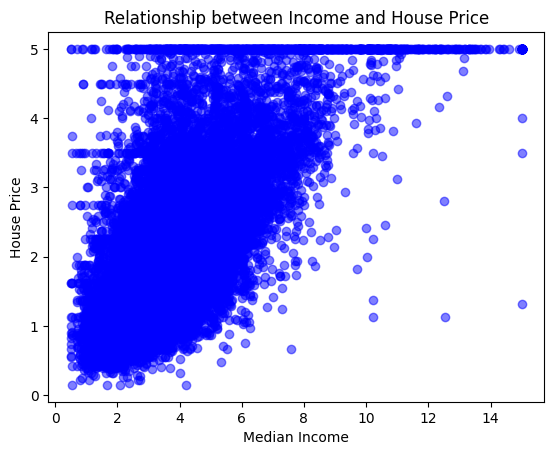

In [10]:
plt.scatter(df['MedInc'], df['PRICE'], color="blue", alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Relationship between Income and House Price")
plt.show()

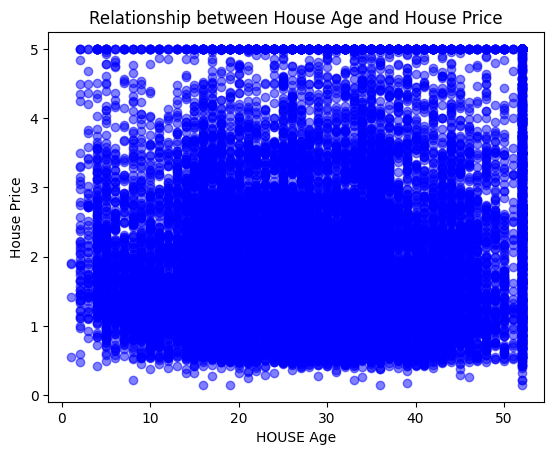

In [11]:
plt.scatter(df['HouseAge'], df['PRICE'], color="blue", alpha=0.5)
plt.xlabel("HOUSE Age")
plt.ylabel("House Price")
plt.title("Relationship between House Age and House Price")
plt.show()

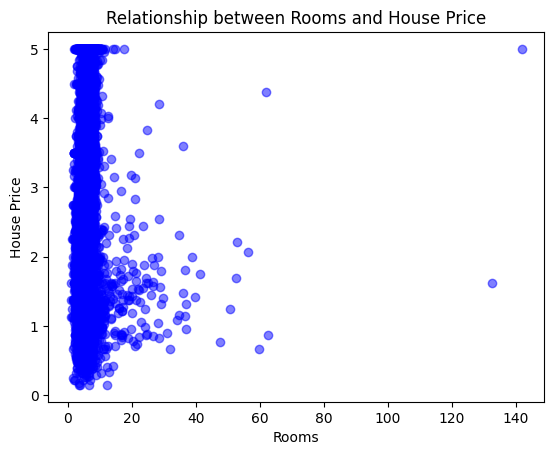

In [12]:
plt.scatter(df['AveRooms'], df['PRICE'], color="blue", alpha=0.5)
plt.xlabel("Rooms")
plt.ylabel("House Price")
plt.title("Relationship between Rooms and House Price")
plt.show()

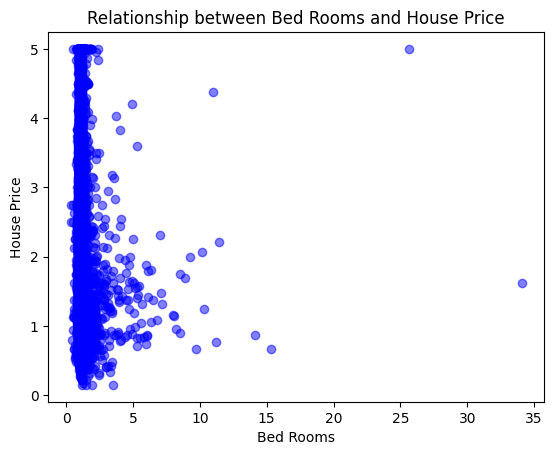

In [13]:
plt.scatter(df['AveBedrms'], df['PRICE'], color="blue", alpha=0.5)
plt.xlabel("Bed Rooms")
plt.ylabel("House Price")
plt.title("Relationship between Bed Rooms and House Price")
plt.show()

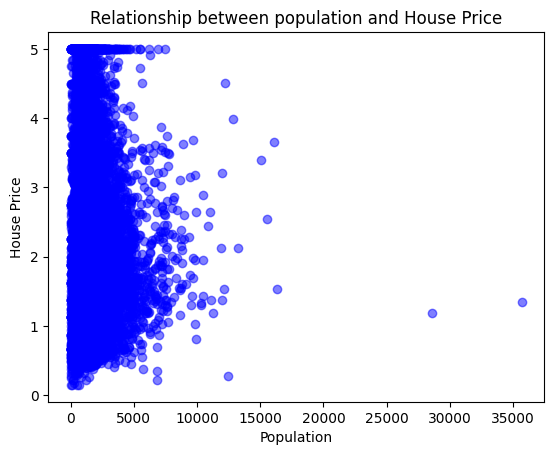

In [14]:
plt.scatter(df['Population'], df['PRICE'], color="blue", alpha=0.5)
plt.xlabel("Population")
plt.ylabel("House Price")
plt.title("Relationship between population and House Price")
plt.show()

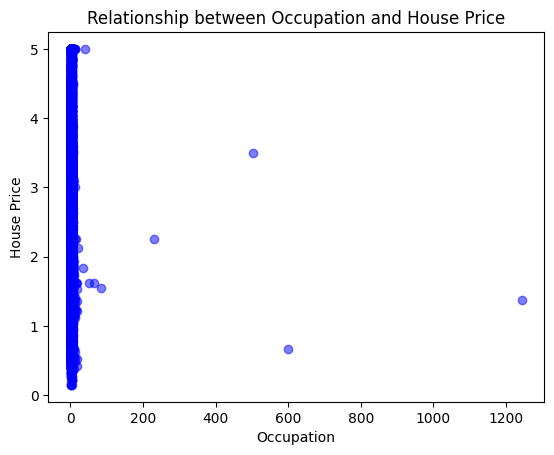

In [15]:
plt.scatter(df['AveOccup'], df['PRICE'], color="blue", alpha=0.5)
plt.xlabel("Occupation")
plt.ylabel("House Price")
plt.title("Relationship between Occupation and House Price")
plt.show()

In [16]:
import seaborn as sns

In [17]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

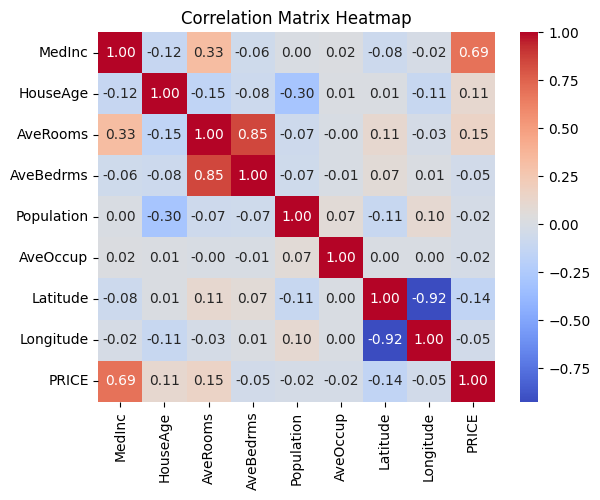

In [18]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [19]:
selected_features = ["MedInc", "AveRooms","AveBedrms", "HouseAge", "AveOccup", "Population",'Latitude', 'Longitude']


In [20]:
# Perpare Data

In [21]:
X = df[selected_features]
y = df["PRICE"]

In [22]:
X

,MedInc,AveRooms,AveBedrms,HouseAge,AveOccup,Population,Latitude,Longitude
0,8.3252,6.984127,1.023810,41.0,2.555556,322.0,37.88,-122.23
1,8.3014,6.238137,0.971880,21.0,2.109842,2401.0,37.86,-122.22
2,7.2574,8.288136,1.073446,52.0,2.802260,496.0,37.85,-122.24
3,5.6431,5.817352,1.073059,52.0,2.547945,558.0,37.85,-122.25
4,3.8462,6.281853,1.081081,52.0,2.181467,565.0,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,5.045455,1.133333,25.0,2.560606,845.0,39.48,-121.09
20636,2.5568,6.114035,1.315789,18.0,3.122807,356.0,39.49,-121.21
20637,1.7000,5.205543,1.120092,17.0,2.325635,1007.0,39.43,-121.22
20638,1.8672,5.329513,1.171920,18.0,2.123209,741.0,39.43,-121.32


In [23]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: PRICE, Length: 20640, dtype: float64

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# train the model

In [26]:
model = LinearRegression()

In [27]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
# make predictions

In [29]:
y_pred = model.predict(X_test)

In [30]:
print("Comparison of Actual vs Predicted Prices:")
for actual, predicted in list(zip(y_test[:10], y_pred[:10])):
    print("Actual:", round(actual, 2), " | Predicted:", round(predicted, 2))

Comparison of Actual vs Predicted Prices:
Actual: 0.48  | Predicted: 0.72
Actual: 0.46  | Predicted: 1.76
Actual: 5.0  | Predicted: 2.71
Actual: 2.19  | Predicted: 2.84
Actual: 2.78  | Predicted: 2.6
Actual: 1.59  | Predicted: 2.01
Actual: 1.98  | Predicted: 2.65
Actual: 1.57  | Predicted: 2.17
Actual: 3.4  | Predicted: 2.74
Actual: 4.47  | Predicted: 3.92


In [31]:
# Evaluate the model

In [32]:
r2 = r2_score(y_test, y_pred) # comperhensive metric to evaluate the model, the definition of r2 is the proportion of the variance in the dependent variable that is predictable from the independent variables.

In [33]:
r2 # the R-squared value

0.5757877060324526